# SVI Parameterization of the Implied Volatility Surface

## From Models to Market Fitting

In Chapters 7 and 9, we saw how stochastic models (Merton, Heston) generate implied volatility smiles. In practice, traders need to **interpolate and extrapolate** the volatility surface from a discrete set of observed option prices. The **SVI (Stochastic Volatility Inspired)** parameterization by Gatheral (2004) is the industry standard for this.

## The SVI Formula

SVI parameterizes the **total implied variance** $w(k) = \sigma_{\text{imp}}^2(k) \cdot T$ as a function of log-moneyness $k = \ln(K/F)$, where $F = S_0 e^{rT}$ is the forward price:

$$w(k) = a + b\left[\rho(k - m) + \sqrt{(k - m)^2 + \sigma^2}\right]$$

### The Five Parameters

| Parameter | Meaning | Constraint |
|-----------|---------|------------|
| $a$ | Overall variance level | $a > -b\sigma\sqrt{1-\rho^2}$ (ensures $w > 0$) |
| $b$ | Slope magnitude (controls wing steepness) | $b \geq 0$ |
| $\rho$ | Skew/rotation of the smile | $-1 < \rho < 1$ |
| $m$ | Horizontal translation (shift of minimum) | $m \in \mathbb{R}$ |
| $\sigma$ | Curvature at the vertex (ATM smoothness) | $\sigma > 0$ |

### Connection to Heston

The name "Stochastic Volatility Inspired" comes from the fact that in the Heston model, the implied total variance at extreme strikes is **asymptotically linear** in $k$ — exactly the behavior that SVI captures. For large $|k|$:

$$w(k) \approx a + b(1 + \rho)k \quad (k \to +\infty), \qquad w(k) \approx a + b(\rho - 1)k \quad (k \to -\infty)$$

The wings have slopes $b(1+\rho)$ and $b(\rho-1)$, controlled by $b$ and $\rho$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, log, sqrt, exp, factorial
from scipy.optimize import minimize
from scipy.integrate import quad
%matplotlib inline

# Black-Scholes formulas (from previous chapters)
def bs_cdf(x):
    return 0.5 * (1 + erf(x / sqrt(2)))

def bs_call(S, K, r, T, sigma):
    d1 = (log(S/K) + (r + sigma**2/2)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    return S * bs_cdf(d1) - K * exp(-r*T) * bs_cdf(d2)

def bs_put(S, K, r, T, sigma):
    d1 = (log(S/K) + (r + sigma**2/2)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    return -S * bs_cdf(-d1) + K * exp(-r*T) * bs_cdf(-d2)

def implied_vol_newton(market_price, S, K, r, T, is_call=True, tol=1e-8, max_iter=100):
    """Find implied vol via Newton-Raphson."""
    sig = 0.3
    for _ in range(max_iter):
        if is_call:
            price = bs_call(S, K, r, T, sig)
        else:
            price = bs_put(S, K, r, T, sig)
        d1 = (log(S/K) + (r + sig**2/2)*T) / (sig*sqrt(T))
        vega = S * np.exp(-d1**2/2) / sqrt(2*np.pi) * sqrt(T)
        diff = price - market_price
        if abs(diff) < tol:
            return sig
        if vega < 1e-12:
            return np.nan
        sig -= diff / vega
        if sig < 1e-6:
            sig = 1e-6
    return np.nan

## 1. Generate Synthetic Market Data from Heston

We use the Heston semi-analytical pricer from Chapter 9 to generate "market" implied volatilities across strikes and maturities. This gives us clean ground truth to calibrate SVI against.

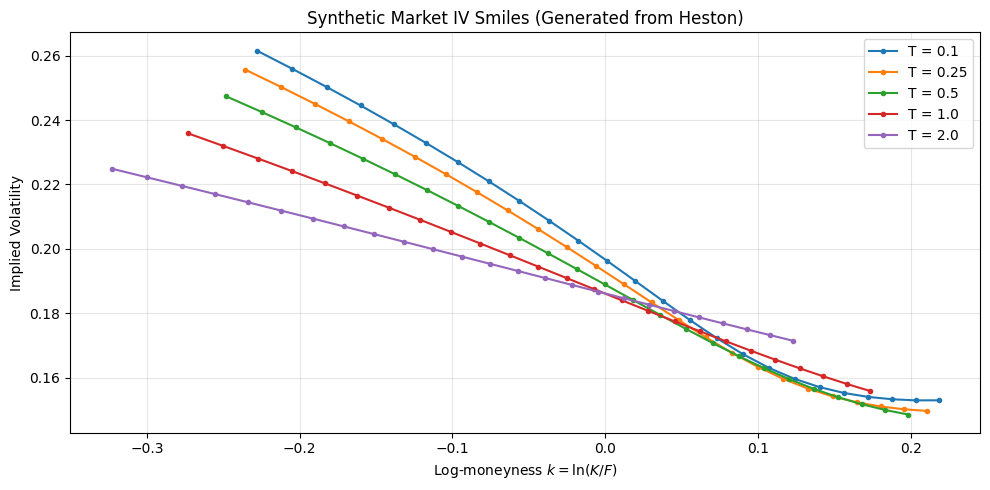

In [2]:
# Heston pricer (from Chapter 9)
def heston_char_func(u, S0, r, T, v0, kappa, theta, xi, rho, j):
    x = np.log(S0)
    if j == 1:
        b = kappa - rho * xi
        u_adj = 0.5
    else:
        b = kappa
        u_adj = -0.5
    d = np.sqrt((rho * xi * 1j * u - b)**2 - xi**2 * (2 * u_adj * 1j * u - u**2))
    g = (b - rho * xi * 1j * u + d) / (b - rho * xi * 1j * u - d)
    C = r * 1j * u * T + (kappa * theta / xi**2) * (
        (b - rho * xi * 1j * u + d) * T - 2 * np.log((1 - g * np.exp(d * T)) / (1 - g))
    )
    D = ((b - rho * xi * 1j * u + d) / xi**2) * ((1 - np.exp(d * T)) / (1 - g * np.exp(d * T)))
    return np.exp(C + D * v0 + 1j * u * x)

def heston_call(S0, K, r, T, v0, kappa, theta, xi, rho):
    def integrand_P(u, j):
        phi = heston_char_func(u, S0, r, T, v0, kappa, theta, xi, rho, j)
        return np.real(np.exp(-1j * u * np.log(K)) * phi / (1j * u))
    I1, _ = quad(lambda u: integrand_P(u, 1), 0, 200, limit=200)
    I2, _ = quad(lambda u: integrand_P(u, 2), 0, 200, limit=200)
    P1 = 0.5 + I1 / np.pi
    P2 = 0.5 + I2 / np.pi
    return S0 * P1 - K * np.exp(-r * T) * P2

def heston_put(S0, K, r, T, v0, kappa, theta, xi, rho):
    return heston_call(S0, K, r, T, v0, kappa, theta, xi, rho) - S0 + K * np.exp(-r * T)

# Heston parameters
S0, r = 100, 0.05
v0 = 0.04
kappa, theta, xi, rho = 2.0, 0.04, 0.4, -0.7

# Generate IV data across maturities and strikes
maturities = [0.1, 0.25, 0.5, 1.0, 2.0]
strikes = np.linspace(80, 125, 25)

import warnings
warnings.filterwarnings('ignore')  # suppress integration warnings

market_data = {}  # {T: (k_array, iv_array)}
for T_i in maturities:
    F = S0 * np.exp(r * T_i)  # forward price
    ivs = []
    for Ki in strikes:
        if Ki < S0:
            hp = heston_put(S0, Ki, r, T_i, v0, kappa, theta, xi, rho)
            iv = implied_vol_newton(hp, S0, Ki, r, T_i, is_call=False)
        else:
            hc = heston_call(S0, Ki, r, T_i, v0, kappa, theta, xi, rho)
            iv = implied_vol_newton(hc, S0, Ki, r, T_i, is_call=True)
        ivs.append(iv)
    ivs = np.array(ivs)
    k = np.log(strikes / F)  # log-moneyness
    market_data[T_i] = (k, ivs)

# Plot the synthetic market IV smiles
fig, ax = plt.subplots(figsize=(10, 5))
for T_i in maturities:
    k, ivs = market_data[T_i]
    ax.plot(k, ivs, 'o-', markersize=3, linewidth=1.5, label=f'T = {T_i}')
ax.set_xlabel(r'Log-moneyness $k = \ln(K/F)$')
ax.set_ylabel('Implied Volatility')
ax.set_title('Synthetic Market IV Smiles (Generated from Heston)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. The SVI Parameterization

The SVI formula maps log-moneyness $k$ to total implied variance $w = \sigma_{\text{imp}}^2 \cdot T$:

$$w(k) = a + b\left[\rho(k - m) + \sqrt{(k - m)^2 + \sigma^2}\right]$$

Let's visualize how each parameter affects the shape.

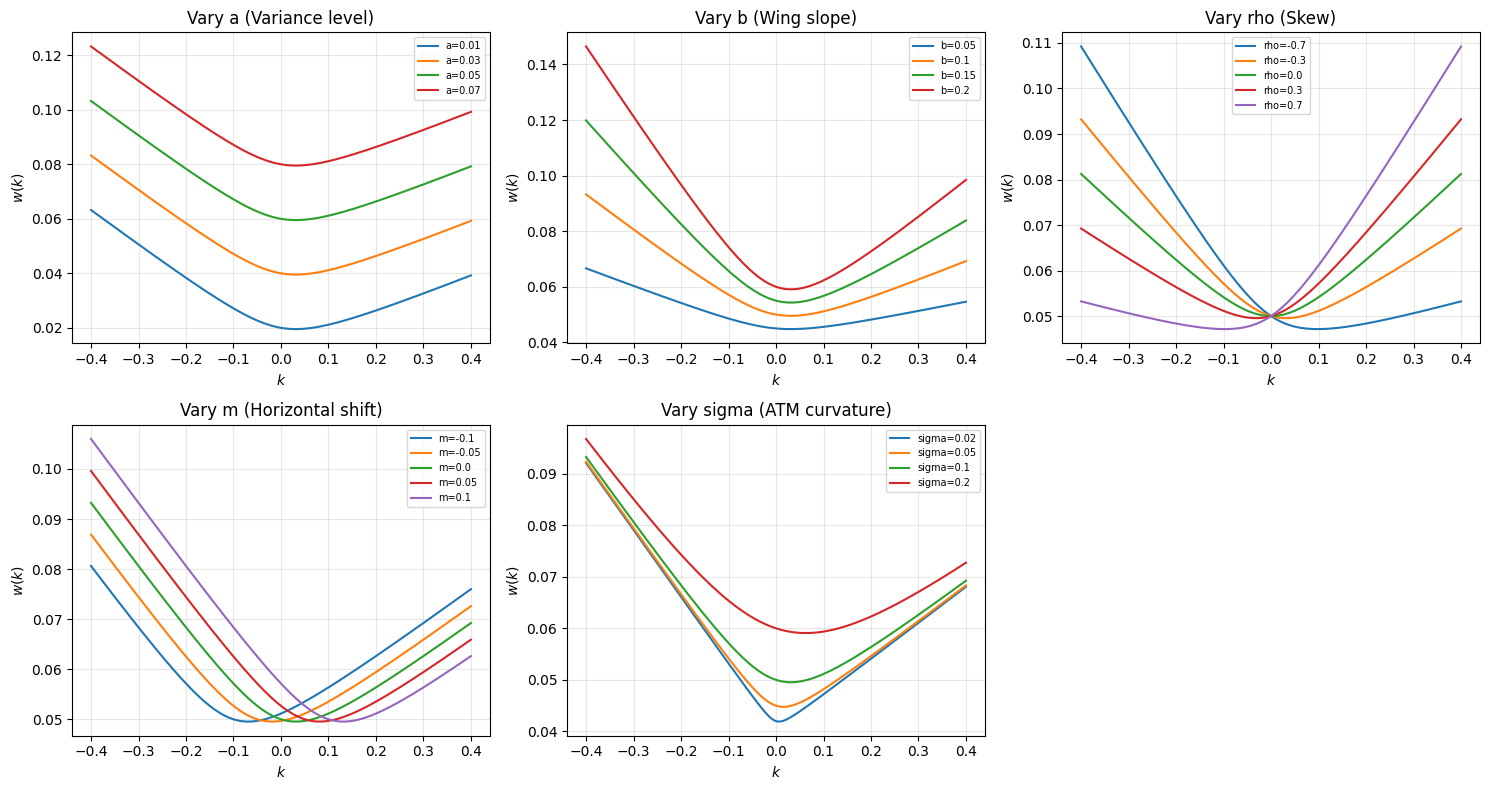

In [3]:
def svi_total_variance(k, a, b, rho, m, sigma):
    """SVI total implied variance w(k) = sigma_imp^2 * T."""
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))

def svi_implied_vol(k, T, a, b, rho, m, sigma):
    """SVI implied volatility sigma_imp(k) = sqrt(w(k) / T)."""
    w = svi_total_variance(k, a, b, rho, m, sigma)
    return np.sqrt(np.maximum(w, 0) / T)

# Demonstrate parameter effects
k_demo = np.linspace(-0.4, 0.4, 200)
base_params = dict(a=0.04, b=0.1, rho=-0.3, m=0.0, sigma=0.1)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Vary each parameter
param_variations = [
    ('a', [0.01, 0.03, 0.05, 0.07], 'Variance level'),
    ('b', [0.05, 0.10, 0.15, 0.20], 'Wing slope'),
    ('rho', [-0.7, -0.3, 0.0, 0.3, 0.7], 'Skew'),
    ('m', [-0.1, -0.05, 0.0, 0.05, 0.1], 'Horizontal shift'),
    ('sigma', [0.02, 0.05, 0.1, 0.2], 'ATM curvature'),
]

for ax, (param, values, desc) in zip(axes.flatten(), param_variations):
    for val in values:
        params = base_params.copy()
        params[param] = val
        w = svi_total_variance(k_demo, **params)
        ax.plot(k_demo, w, linewidth=1.5, label=f'{param}={val}')
    ax.set_xlabel(r'$k$')
    ax.set_ylabel(r'$w(k)$')
    ax.set_title(f'Vary {param} ({desc})')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

axes[1, 2].set_visible(False)
plt.tight_layout()
plt.show()

## 3. SVI Calibration

For each maturity slice, we fit the SVI parameters $(a, b, \rho, m, \sigma)$ by minimizing the sum of squared errors between the SVI total variance and the market total variance:

$$\min_{a,b,\rho,m,\sigma} \sum_i \left[w_{\text{SVI}}(k_i) - \sigma_{\text{mkt},i}^2 \cdot T\right]^2$$

subject to the constraints $b \geq 0$, $|\rho| < 1$, $\sigma > 0$, and $a + b\sigma\sqrt{1-\rho^2} \geq 0$ (non-negative variance).

In [4]:
from scipy.optimize import differential_evolution

def calibrate_svi(k, iv_market, T):
    """
    Calibrate SVI parameters to market implied volatilities via
    differential evolution (global optimizer).
    """
    w_market = iv_market**2 * T  # total variance
    
    # Filter out any NaN values
    valid = np.isfinite(w_market) & np.isfinite(k)
    k_valid = k[valid]
    w_valid = w_market[valid]
    
    def objective(params):
        a, b, rho, m, sigma = params
        w_svi = svi_total_variance(k_valid, a, b, rho, m, sigma)
        return np.sum((w_svi - w_valid)**2)
    
    k_range = k_valid.max() - k_valid.min()
    bounds = [
        (-0.1, 0.5),              # a
        (1e-6, 1.0),              # b
        (-0.999, 0.999),          # rho
        (k_valid.min(), k_valid.max()),  # m: within data range
        (1e-4, k_range),          # sigma
    ]
    
    result = differential_evolution(objective, bounds, seed=42, maxiter=3000,
                                    tol=1e-14, polish=True, popsize=30)
    
    a, b, rho, m, sigma = result.x
    
    # Compute RMSE of implied vol
    w_fit = svi_total_variance(k_valid, a, b, rho, m, sigma)
    iv_fit = np.sqrt(np.maximum(w_fit, 0) / T)
    iv_rmse = np.sqrt(np.mean((iv_fit - iv_market[valid])**2))
    
    return {'a': a, 'b': b, 'rho': rho, 'm': m, 'sigma': sigma, 
            'fun': result.fun, 'iv_rmse': iv_rmse, 'success': result.success}


# Calibrate SVI for each maturity
svi_fits = {}
print("=== SVI Calibration Results ===")
print(f"{'T':>5s} {'a':>8s} {'b':>8s} {'rho':>8s} {'m':>8s} {'sigma':>8s} {'IV RMSE(bps)':>13s}")

for T_i in maturities:
    k, iv = market_data[T_i]
    fit = calibrate_svi(k, iv, T_i)
    svi_fits[T_i] = fit
    
    print(f"{T_i:5.2f} {fit['a']:8.5f} {fit['b']:8.5f} {fit['rho']:8.5f} {fit['m']:8.5f} {fit['sigma']:8.5f} {fit['iv_rmse']*10000:13.2f}")

=== SVI Calibration Results ===
    T        a        b      rho        m    sigma  IV RMSE(bps)


 0.10  0.00226  0.00666 -0.99900  0.11630  0.04769          3.17


 0.25  0.00533  0.01533 -0.99900  0.12322  0.05957          2.53


 0.50  0.00976  0.02667 -0.99900  0.13853  0.09080          1.26


 1.00  0.01807  0.04092 -0.99900  0.17314  0.15438          0.66


 2.00  0.05611  0.04996 -0.99900  0.12314  0.06442          2.47


## 4. Visualize SVI Fits

Overlay the calibrated SVI curves on the Heston-generated market data.

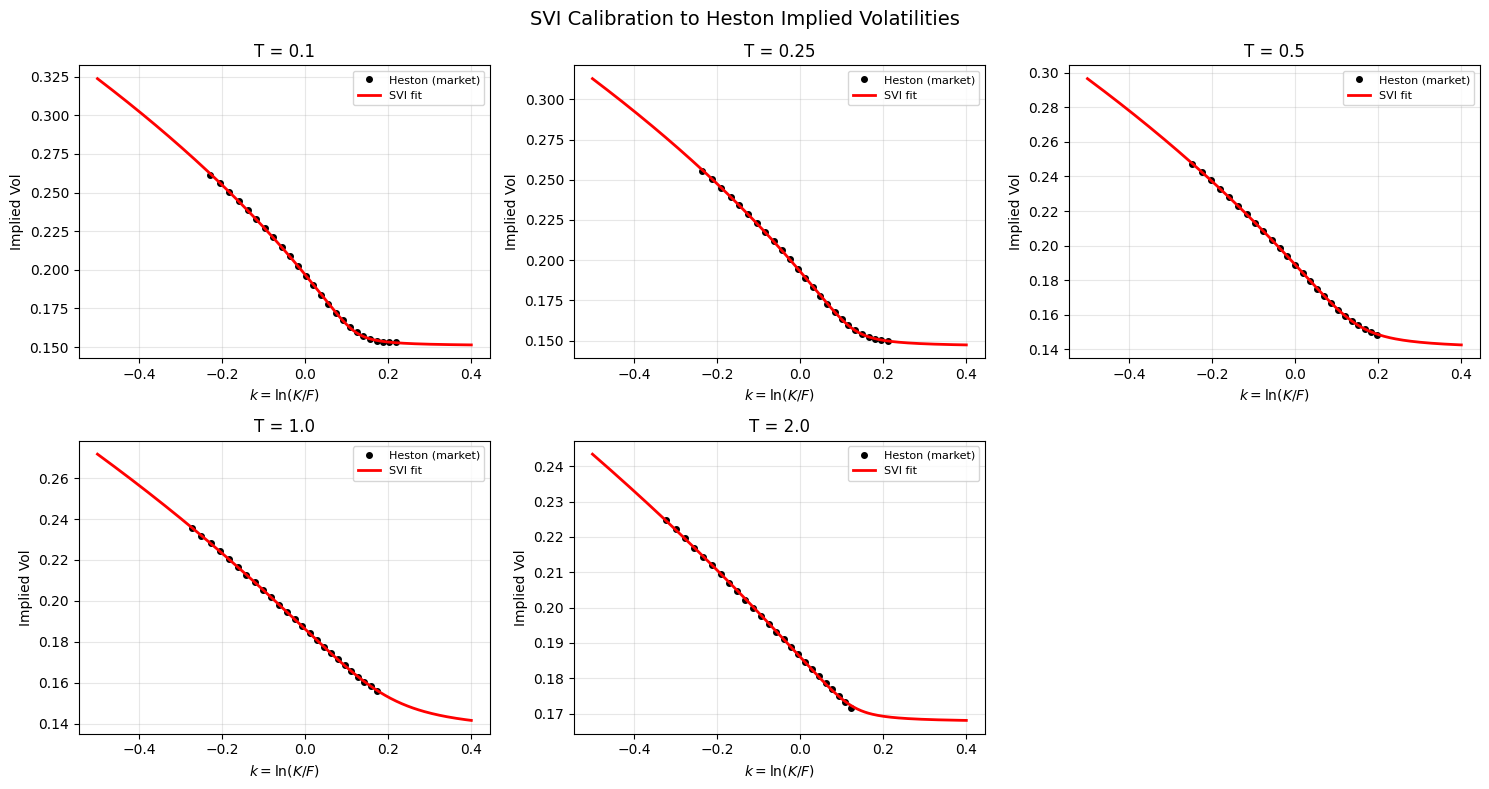

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
k_fine = np.linspace(-0.5, 0.4, 200)

for idx, T_i in enumerate(maturities):
    ax = axes.flatten()[idx]
    k, iv = market_data[T_i]
    fit = svi_fits[T_i]
    
    # Market IV
    ax.plot(k, iv, 'ko', markersize=4, label='Heston (market)')
    
    # SVI fit
    iv_svi = svi_implied_vol(k_fine, T_i, fit['a'], fit['b'], fit['rho'], fit['m'], fit['sigma'])
    ax.plot(k_fine, iv_svi, 'r-', linewidth=2, label='SVI fit')
    
    ax.set_xlabel(r'$k = \ln(K/F)$')
    ax.set_ylabel('Implied Vol')
    ax.set_title(f'T = {T_i}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[1, 2].set_visible(False)
plt.suptitle('SVI Calibration to Heston Implied Volatilities', fontsize=14)
plt.tight_layout()
plt.show()

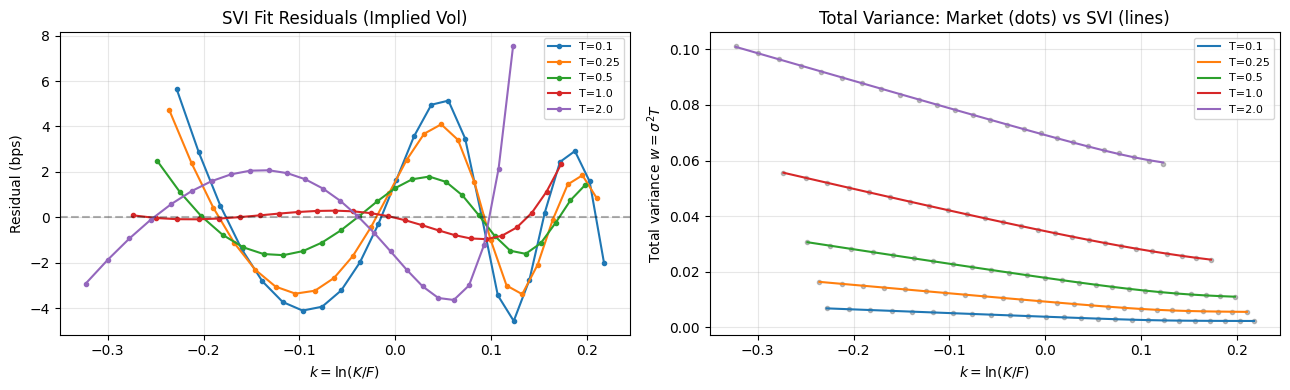

In [6]:
# Residual analysis
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) IV residuals per slice
for T_i in maturities:
    k, iv = market_data[T_i]
    fit = svi_fits[T_i]
    iv_svi = svi_implied_vol(k, T_i, fit['a'], fit['b'], fit['rho'], fit['m'], fit['sigma'])
    residuals = (iv_svi - iv) * 10000  # in basis points
    axes[0].plot(k, residuals, 'o-', markersize=3, label=f'T={T_i}')

axes[0].axhline(0, color='k', linestyle='--', alpha=0.3)
axes[0].set_xlabel(r'$k = \ln(K/F)$')
axes[0].set_ylabel('Residual (bps)')
axes[0].set_title('SVI Fit Residuals (Implied Vol)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# (b) Total variance fit quality
for T_i in maturities:
    k, iv = market_data[T_i]
    fit = svi_fits[T_i]
    w_market = iv**2 * T_i
    w_svi = svi_total_variance(k, fit['a'], fit['b'], fit['rho'], fit['m'], fit['sigma'])
    axes[1].plot(k, w_market, 'o', markersize=3, color='gray', alpha=0.5)
    axes[1].plot(k, w_svi, '-', linewidth=1.5, label=f'T={T_i}')

axes[1].set_xlabel(r'$k = \ln(K/F)$')
axes[1].set_ylabel(r'Total variance $w = \sigma^2 T$')
axes[1].set_title('Total Variance: Market (dots) vs SVI (lines)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Interpolated Volatility Surface

With SVI fitted at each maturity, we can build a full implied volatility surface by interpolating the SVI parameters across maturities.

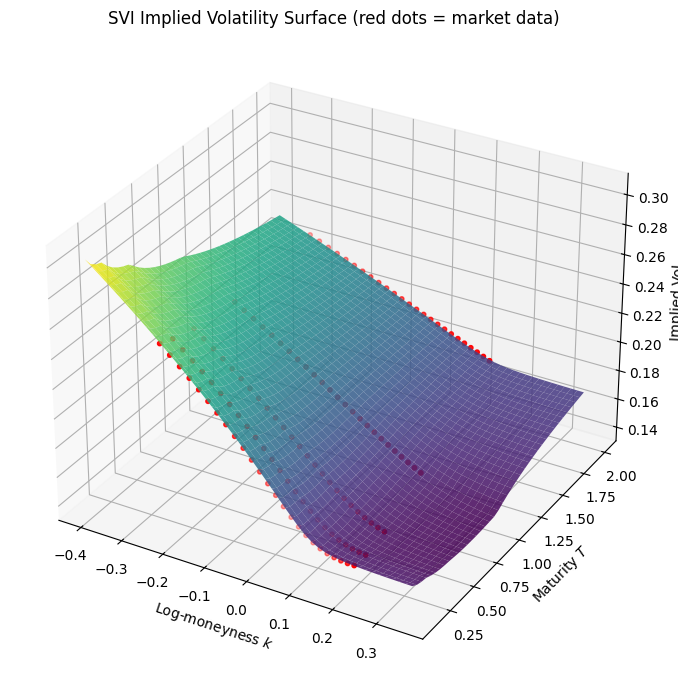

In [7]:
from scipy.interpolate import interp1d

# Extract fitted parameters as arrays
T_arr = np.array(maturities)
param_names = ['a', 'b', 'rho', 'm', 'sigma']
param_arrays = {p: np.array([svi_fits[T_i][p] for T_i in maturities]) for p in param_names}

# Interpolate each parameter linearly in T
param_interp = {p: interp1d(T_arr, param_arrays[p], kind='linear', fill_value='extrapolate')
                for p in param_names}

# Build surface
T_surface = np.linspace(0.1, 2.0, 40)
k_surface = np.linspace(-0.4, 0.35, 50)
K_grid, T_grid = np.meshgrid(k_surface, T_surface)
iv_svi_surface = np.zeros_like(K_grid)

for i, T_i in enumerate(T_surface):
    params = {p: float(param_interp[p](T_i)) for p in param_names}
    iv_svi_surface[i, :] = svi_implied_vol(k_surface, T_i, **params)

# 3D surface plot
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(K_grid, T_grid, iv_svi_surface, cmap='viridis', alpha=0.85)

# Overlay market data points
for T_i in maturities:
    k, iv = market_data[T_i]
    ax.scatter(k, np.full_like(k, T_i), iv, color='red', s=10, zorder=5)

ax.set_xlabel(r'Log-moneyness $k$')
ax.set_ylabel('Maturity $T$')
ax.set_zlabel('Implied Vol')
ax.set_title('SVI Implied Volatility Surface (red dots = market data)')
plt.tight_layout()
plt.show()

## 6. No-Arbitrage Constraints

Not every set of SVI parameters gives an arbitrage-free surface. We check three conditions:

### (a) Non-negative variance
$$w(k) \geq 0 \quad \forall k$$
Guaranteed if $a + b\sigma\sqrt{1-\rho^2} \geq 0$.

### (b) Roger Lee's moment formula (slope bound)
The slope of total variance must satisfy:
$$\left|\frac{\partial w}{\partial k}\right| \leq 2$$
This ensures the call price spread $\partial C / \partial K$ stays in $[-e^{-rT}, 0]$.

### (c) No butterfly arbitrage (Durrleman's condition)
The density implied by the option prices must be non-negative:
$$g(k) = \left(1 - \frac{k w'}{2w}\right)^2 - \frac{(w')^2}{4}\left(\frac{1}{w} + \frac{1}{4}\right) + \frac{w''}{2} \geq 0$$

where $w' = dw/dk$ and $w'' = d^2w/dk^2$.

In [8]:
def svi_derivatives(k, a, b, rho, m, sigma):
    """Compute w, w', w'' for the SVI parameterization."""
    z = k - m
    s = np.sqrt(z**2 + sigma**2)
    w = a + b * (rho * z + s)
    dw = b * (rho + z / s)          # dw/dk
    d2w = b * sigma**2 / s**3       # d2w/dk2
    return w, dw, d2w


def check_arbitrage(k, T, a, b, rho, m, sigma):
    """Check no-arbitrage conditions for an SVI slice."""
    w, dw, d2w = svi_derivatives(k, a, b, rho, m, sigma)
    
    # (a) Non-negative variance
    min_w = a + b * sigma * np.sqrt(1 - rho**2)
    w_ok = min_w >= -1e-10
    
    # (b) Slope bound: |dw/dk| <= 2
    max_slope = np.max(np.abs(dw))
    slope_ok = max_slope <= 2.0 + 1e-10
    
    # (c) Durrleman's condition: g(k) >= 0
    w_safe = np.maximum(w, 1e-12)
    g = (1 - k * dw / (2 * w_safe))**2 - (dw**2 / 4) * (1/w_safe + 0.25) + d2w / 2
    min_g = np.min(g)
    butterfly_ok = min_g >= -1e-10
    
    return w_ok, slope_ok, butterfly_ok, min_w, max_slope, min_g, g


# Check arbitrage conditions for each fitted slice
k_check = np.linspace(-0.6, 0.5, 500)

print("=== No-Arbitrage Checks ===")
print(f"{'T':>5s} {'w>=0':>8s} {'slope<=2':>10s} {'butterfly':>10s} {'min(w)':>10s} {'max|dw|':>10s} {'min(g)':>10s}")

for T_i in maturities:
    fit = svi_fits[T_i]
    w_ok, slope_ok, bfly_ok, min_w, max_slope, min_g, _ = check_arbitrage(
        k_check, T_i, fit['a'], fit['b'], fit['rho'], fit['m'], fit['sigma']
    )
    print(f"{T_i:5.2f} {'PASS' if w_ok else 'FAIL':>8s} {'PASS' if slope_ok else 'FAIL':>10s} "
          f"{'PASS' if bfly_ok else 'FAIL':>10s} {min_w:10.6f} {max_slope:10.6f} {min_g:10.6f}")

=== No-Arbitrage Checks ===
    T     w>=0   slope<=2  butterfly     min(w)    max|dw|     min(g)
 0.10     PASS       PASS       PASS   0.002278   0.013298   0.434803
 0.25     PASS       PASS       PASS   0.005370   0.030586   0.435910
 0.50     PASS       PASS       PASS   0.009865   0.053123   0.443618
 1.00     PASS       PASS       PASS   0.018353   0.081016   0.475334
 2.00     PASS       PASS       PASS   0.056255   0.099679   0.568985


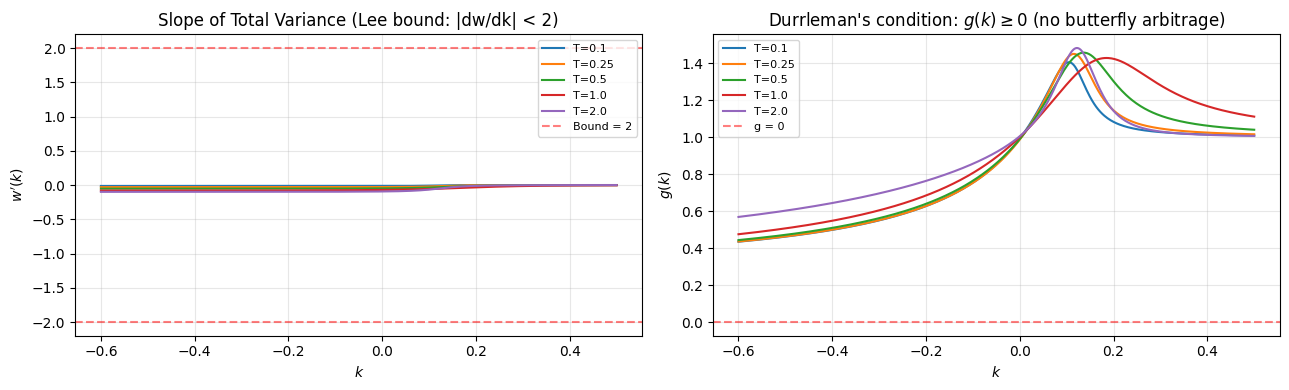

In [9]:
# Visualize the Durrleman density condition
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) dw/dk for each slice
for T_i in maturities:
    fit = svi_fits[T_i]
    _, dw, _ = svi_derivatives(k_check, fit['a'], fit['b'], fit['rho'], fit['m'], fit['sigma'])
    axes[0].plot(k_check, dw, linewidth=1.5, label=f'T={T_i}')

axes[0].axhline(2, color='r', linestyle='--', alpha=0.5, label='Bound = 2')
axes[0].axhline(-2, color='r', linestyle='--', alpha=0.5)
axes[0].set_xlabel(r'$k$')
axes[0].set_ylabel(r"$w'(k)$")
axes[0].set_title('Slope of Total Variance (Lee bound: |dw/dk| < 2)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# (b) Durrleman's g(k)
for T_i in maturities:
    fit = svi_fits[T_i]
    _, _, _, _, _, _, g = check_arbitrage(
        k_check, T_i, fit['a'], fit['b'], fit['rho'], fit['m'], fit['sigma']
    )
    axes[1].plot(k_check, g, linewidth=1.5, label=f'T={T_i}')

axes[1].axhline(0, color='r', linestyle='--', alpha=0.5, label='g = 0')
axes[1].set_xlabel(r'$k$')
axes[1].set_ylabel(r'$g(k)$')
axes[1].set_title(r"Durrleman's condition: $g(k) \geq 0$ (no butterfly arbitrage)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

The SVI parameterization provides a practical, parsimonious way to fit implied volatility smiles:

$$w(k) = a + b\left[\rho(k - m) + \sqrt{(k - m)^2 + \sigma^2}\right]$$

| Parameter | Controls | Effect on smile |
|-----------|----------|----------------|
| $a$ | Variance level | Shifts smile up/down |
| $b$ | Wing steepness | Steeper wings at large $k$ |
| $\rho$ | Skew/asymmetry | Tilts smile left ($\rho<0$) or right |
| $m$ | Horizontal shift | Moves smile center |
| $\sigma$ | ATM curvature | Rounder ($\sigma$ large) vs sharper vertex |

Key takeaways:
- SVI fits 5 parameters per maturity slice to capture the full smile shape
- The name "SVI" comes from the asymptotic behavior of stochastic vol models like Heston — total variance is linear in $k$ at extreme strikes
- **Calibration** is a simple least-squares optimization with box constraints
- **No-arbitrage** requires checking: non-negative variance, Roger Lee's slope bound ($|w'| \leq 2$), and Durrleman's butterfly condition ($g(k) \geq 0$)
- Interpolating SVI parameters across maturities builds a full volatility surface suitable for pricing and hedging